# Auto-Adaptive Localization in PET

**`AutoAdaptiveLocalization`** suppresses spurious sample correlations between state parameters and observations by estimating a noise threshold from shuffled ensembles and setting correlations below it to zero (or tapering them smoothly).

This tutorial covers:
1. The maths behind correlation thresholding
2. The three threshold modes: `adaptive`, `fixed`, `universal`
3. The three taper types: `hard`, `soft`, `sigm`
4. How to configure it in a TOML file
5. Visualising the taper matrix on a synthetic example

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pipt.localization import AutoAdaptiveLocalization

## 1. Synthetic ensemble

We build one illustrative synthetic case used in all sections: a 50x50 state field with one observation and a known localized Gaussian influence pattern. This makes taper behavior visually easy to interpret across threshold and taper options.

In [27]:
rng = np.random.default_rng(42)
n = 50
ne = 120
nx_ny = n * n
n_obs = 1

# Shared synthetic case for the whole tutorial
X = 0.8 * rng.standard_normal((nx_ny, ne))
Y = 0.8 * rng.standard_normal((n_obs, ne))

# Known localized Gaussian influence centered near the upper-left region
yy, xx = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
cy, cx = 16, 14
dist2 = (yy - cy) ** 2 + (xx - cx) ** 2
influence = np.exp(-dist2 / (2 * 7.0**2)).reshape(-1)
influence /= influence.max()

# Inject one latent signal into X and Y with spatially varying strength
signal = rng.standard_normal(ne)
X += (2.5 * influence)[:, None] * signal[None, :]
Y[0] += 2.5 * signal

print(f"X shape: {X.shape}, Y shape: {Y.shape}")
print(f"Shared case: n={n}, ne={ne}, center=({cy}, {cx})")

X shape: (2500, 120), Y shape: (1, 120)
Shared case: n=50, ne=120, center=(16, 14)


## 2. Threshold modes

| Mode | Formula | When to use |
|------|---------|-------------|
| `adaptive` *(default)* | `cutoff × σ_noise` | General purpose; `cutoff` tunes sensitivity |
| `fixed` | `cutoff` directly | When you want a hard, reproducible cut-off |
| `universal` | `√(2 log N) × σ_noise` | Automatic; no `cutoff` tuning needed |

`σ_noise` is estimated column-wise from shuffled correlations using the MAD estimator.

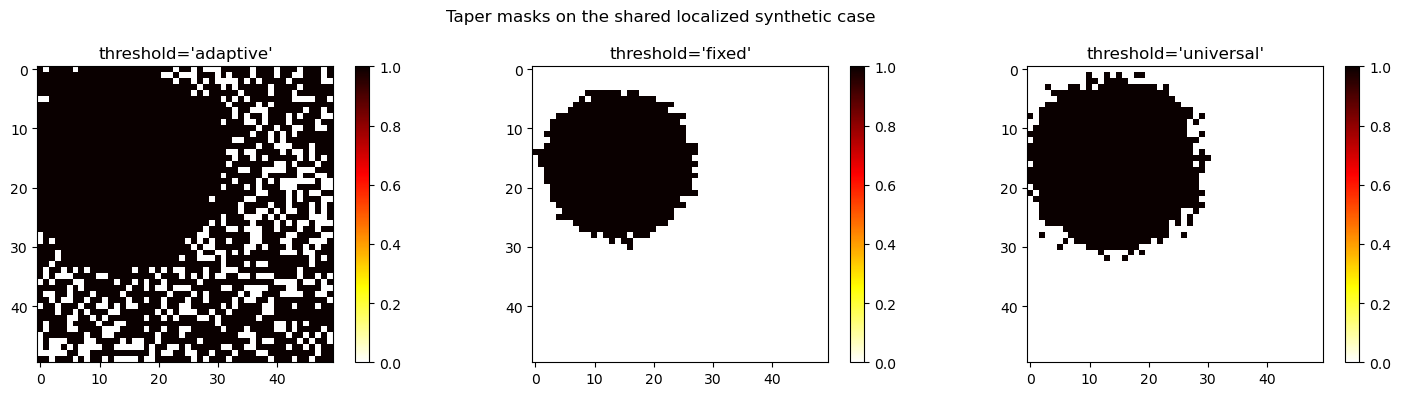

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (mode, kw) in zip(axes, [
    ("adaptive",  {"threshold": "adaptive",  "cutoff": 0.5}),
    ("fixed",     {"threshold": "fixed",     "cutoff": 0.5}),
    ("universal", {"threshold": "universal", "cutoff": 0.5}),
]):
    loc = AutoAdaptiveLocalization({"name": "autoadaloc", "field": [n, n], **kw})
    taper = loc(X, Y, parameters=["PORO"], prior_info={"PORO": {"active": nx_ny}})
    im = ax.imshow(taper[:, 0].reshape(n, n), cmap="hot_r", vmin=0, vmax=1)
    ax.set_title(f"threshold='{mode}'")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Taper masks on the shared localized synthetic case")
plt.tight_layout()
plt.show()

## 3. Taper types (illustrative case)

Once the threshold is known, three strategies apply.
To make the differences obvious, we build a synthetic case with a known localized Gaussian influence around one observation.

| Type | Shape | Notes |
|------|-------|-------|
| `hard` *(default)* | Binary 0/1 | Fastest; sharp cut-off |
| `soft` | Smooth rational function | Gradual transition around threshold |
| `sigm` | Sigmoid | Smooth transition; steeper than `soft` near the threshold |

In the profile plots, the dashed black line is the injected influence pattern (normalized), used as a visual reference.

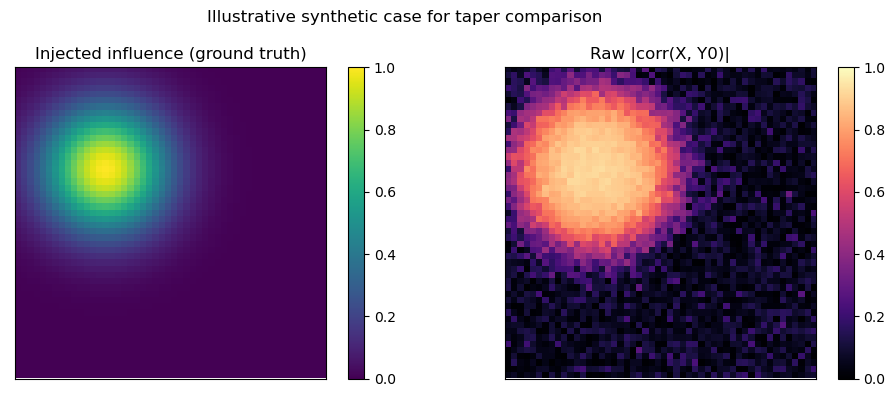

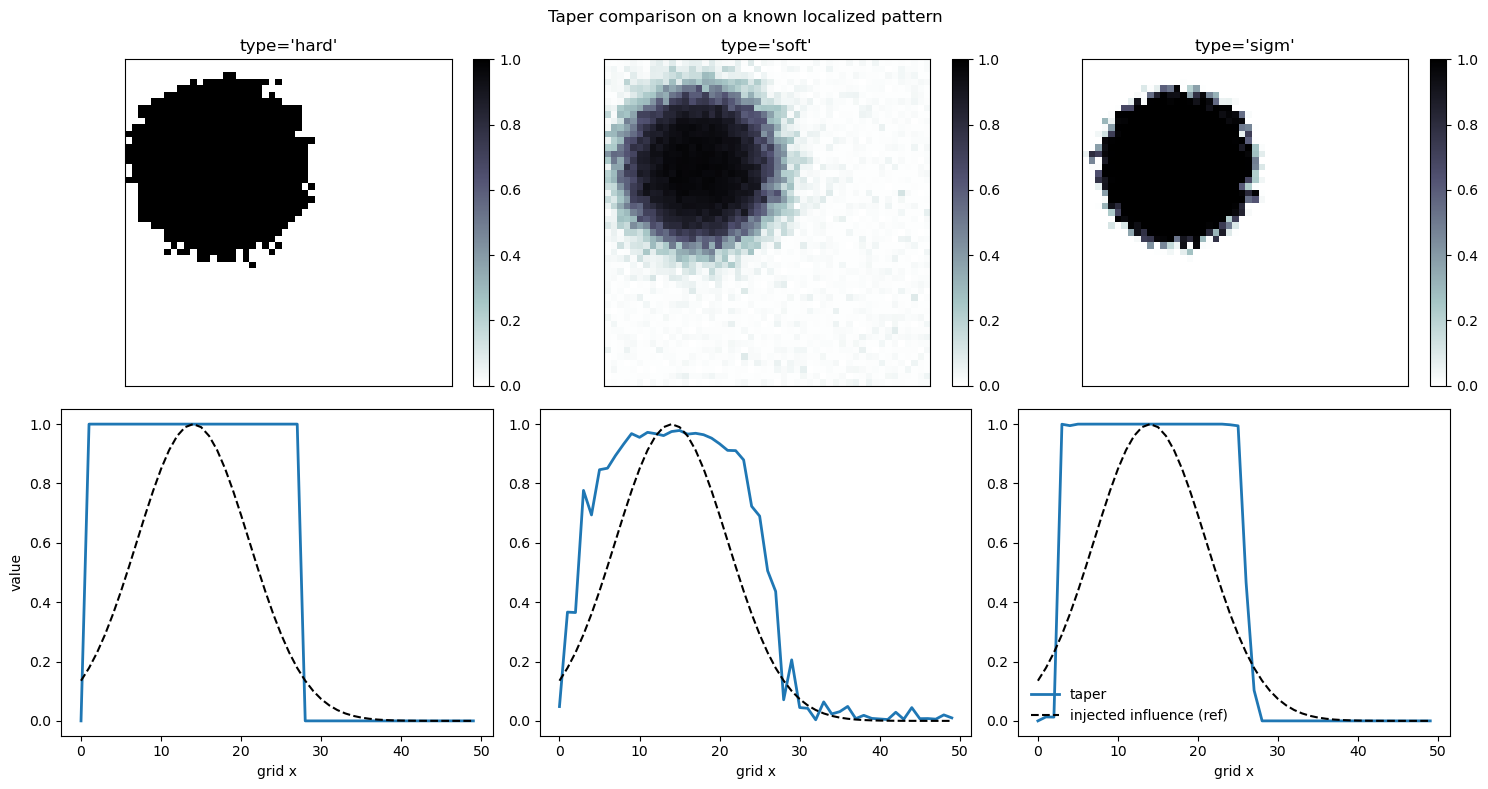

In [44]:
# Reuse the same shared synthetic case from Section 1
raw_corr = np.abs(AutoAdaptiveLocalization.corr_matrix(X, Y)[:, 0]).reshape(n, n)

fig0, ax0 = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax0[0].imshow(influence.reshape(n, n), cmap="viridis", vmin=0, vmax=1)
ax0[0].set_title("Injected influence (ground truth)")
ax0[0].set_xticks([])
ax0[0].set_yticks([])
plt.colorbar(im0, ax=ax0[0], fraction=0.046)

im1 = ax0[1].imshow(raw_corr, cmap="magma", vmin=0, vmax=1)
ax0[1].set_title("Raw |corr(X, Y0)|")
ax0[1].set_xticks([])
ax0[1].set_yticks([])
plt.colorbar(im1, ax=ax0[1], fraction=0.046)

plt.suptitle("Illustrative synthetic case for taper comparison")
plt.tight_layout()
plt.show()

# Compare taper types using a fixed threshold
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="row")
for j, ttype in enumerate(["hard", "soft", "sigm"]):
    loc = AutoAdaptiveLocalization({
        "name": "autoadaloc",
        "field": [n, n],
        "threshold": "fixed",
        "cutoff": 0.4,
        "type": ttype,
    })

    taper = loc(
        X,
        Y,
        parameters=["PORO"],
        prior_info={"PORO": {"active": nx_ny}},
    )

    taper2d = taper[:, 0].reshape(n, n)

    # Row 1: spatial taper map
    im = axes[0, j].imshow(taper2d, cmap="bone_r", vmin=0, vmax=1)
    axes[0, j].set_title(f"type='{ttype}'")
    axes[0, j].set_xticks([])
    axes[0, j].set_yticks([])
    plt.colorbar(im, ax=axes[0, j], fraction=0.046)

    # Row 2: center-row profile against injected influence
    taper_line = taper2d[cy, :]
    ref_line = influence.reshape(n, n)[cy, :]
    axes[1, j].plot(taper_line, lw=2, label="taper")
    axes[1, j].plot(ref_line, "k--", lw=1.5, label="injected influence (ref)")
    axes[1, j].set_ylim(-0.05, 1.05)
    axes[1, j].set_xlabel("grid x")
    if j == 0:
        axes[1, j].set_ylabel("value")
    if j == 2:
        axes[1, j].legend(loc="lower left", frameon=False)

plt.suptitle("Taper comparison on a known localized pattern")
plt.tight_layout()
plt.show()

## 4. Effect of `cutoff`

Higher `cutoff` → stricter suppression → sparser taper. Lower values let more correlations through.

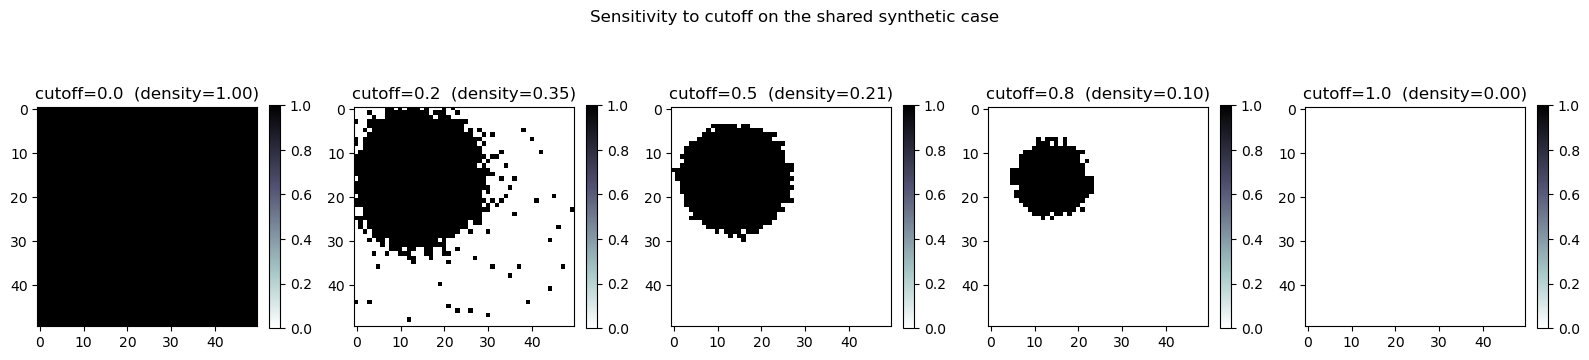

In [43]:
cutoffs = [0.0, 0.2, 0.5, 0.8, 1.0]
fig, axes = plt.subplots(1, len(cutoffs), figsize=(16, 4))

for ax, c in zip(axes, cutoffs):
    loc = AutoAdaptiveLocalization({
        "name": "autoadaloc", "field": [n, n],
        "threshold": "fixed", "cutoff": c,
    })
    taper = loc(X, Y, parameters=["PORO"], prior_info={"PORO": {"active": nx_ny}})
    density = taper[:, 0].mean()
    im = ax.imshow(taper[:, 0].reshape(n, n), cmap="bone_r", vmin=0, vmax=1)
    ax.set_title(f"cutoff={c}  (density={density:.2f})")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Sensitivity to cutoff on the shared synthetic case")
plt.tight_layout()
plt.show()

## 5. TOML / YAML configuration

**TOML:**
```toml
[dataassim.localization]
name      = "autoadaloc"
field     = [1, 50, 50]   # [nz, nx, ny]
threshold = "adaptive"    # default
cutoff    = 1.5
type      = "hard"        # default
```

**YAML:**
```yaml
dataassim:
  localization:
    name:      autoadaloc
    field:     [1, 50, 50]
    threshold: adaptive    # default
    cutoff:    1.5
    type:      hard        # default
```

All keys are optional except `name` and `field`. The minimal block is:

```toml
[dataassim.localization]
name  = "autoadaloc"
field = [50, 50]
```
```yaml
dataassim:
  localization:
    name:  autoadaloc
    field: [50, 50]
```